In [1]:
from reviews_over_time import plot_reviews_over_time
from stats_tests import run_tests

Completed filter + merge of metadata.


/Users/saathvikdirisala/Documents/ece143/final_project/AmazonReviewsDataAnalysis/reviews_over_time/reviews_over_time.py:37: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  flattened_data = continuous_data.groupby(level=0, axis=1).mean()


Completed filter + merge of metadata.


/Users/saathvikdirisala/Documents/ece143/final_project/AmazonReviewsDataAnalysis/reviews_over_time/reviews_over_time.py:37: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  flattened_data = continuous_data.groupby(level=0, axis=1).mean()


Completed filter + merge of metadata.


...

/Users/saathvikdirisala/Documents/ece143/final_project/AmazonReviewsDataAnalysis/reviews_over_time/reviews_over_time.py:37: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  flattened_data = continuous_data.groupby(level=0, axis=1).mean()


Completed filter + merge of metadata.


/Users/saathvikdirisala/Documents/ece143/final_project/AmazonReviewsDataAnalysis/reviews_over_time/reviews_over_time.py:37: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  flattened_data = continuous_data.groupby(level=0, axis=1).mean()


Completed filter + merge of metadata.


/Users/saathvikdirisala/Documents/ece143/final_project/AmazonReviewsDataAnalysis/reviews_over_time/reviews_over_time.py:37: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  flattened_data = continuous_data.groupby(level=0, axis=1).mean()


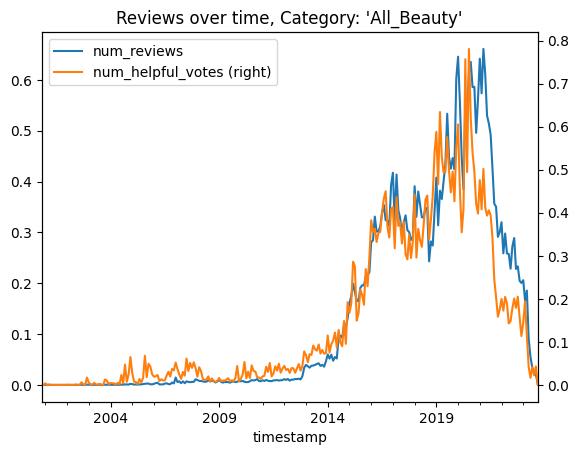

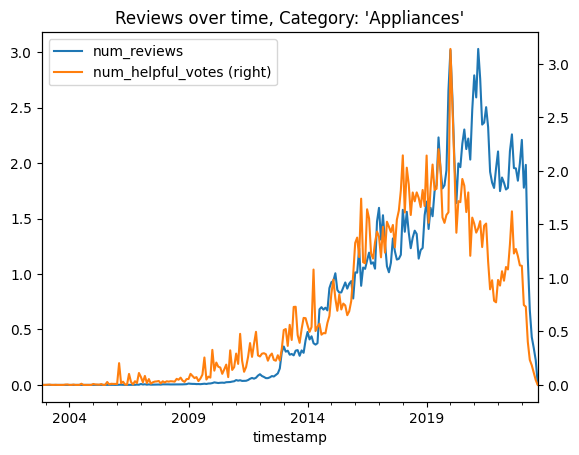

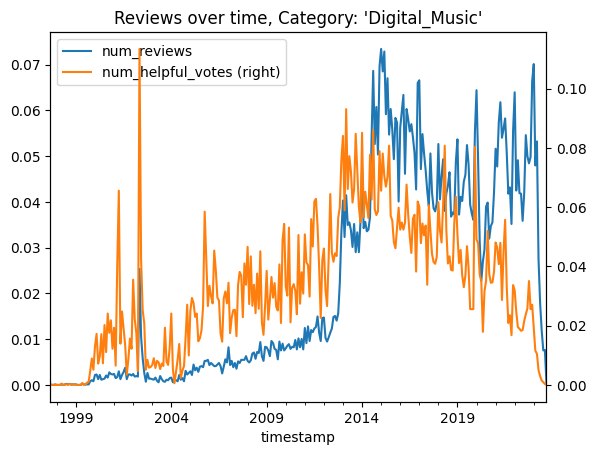

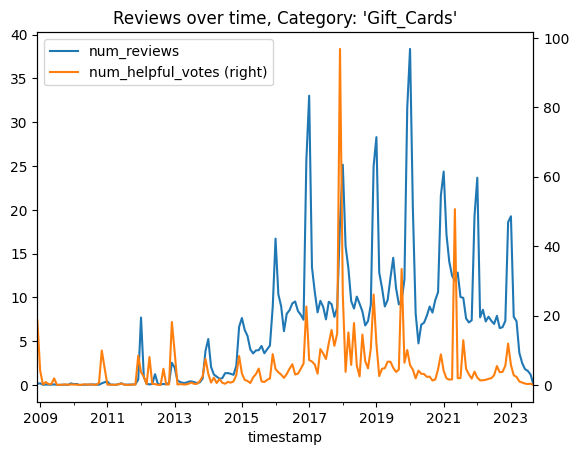

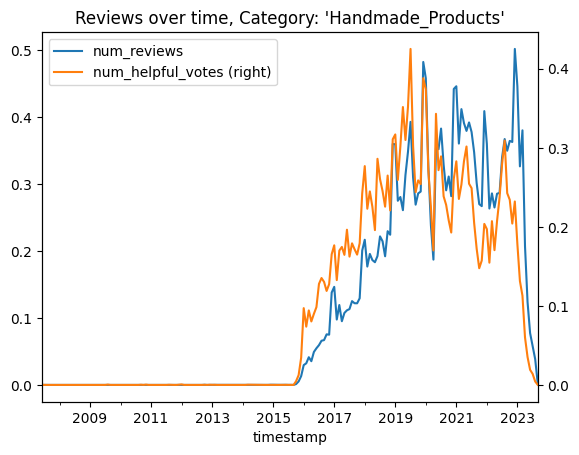

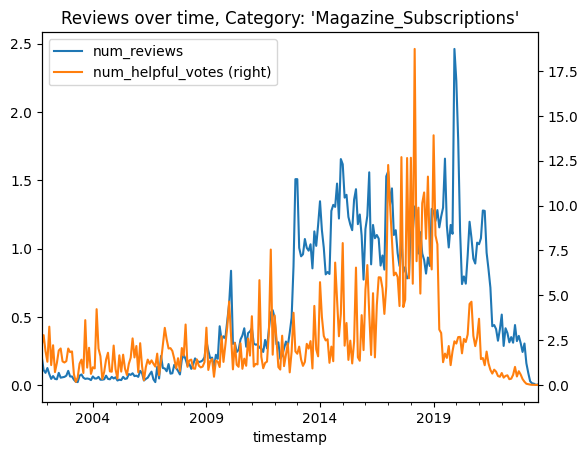

In [2]:
categories = ["All_Beauty", "Appliances","Digital_Music", "Gift_Cards", "Handmade_Products", "Magazine_Subscriptions"]
plot_data = dict()
for category in categories:
    time, num_reviews, helpful_votes = plot_reviews_over_time(category)
    plot_data[category] = [time, num_reviews, helpful_votes]

In [3]:
# # Uncomment cell to generate a single figure with all the time series plots

# import matplotlib.pyplot as plt
# import matplotlib.image as mpimg
# import os

# contents = os.listdir("plots/")
# contents = list(filter(lambda x: x[0].upper() == x[0], contents))
# image_files = list(map(lambda x: "plots/" + x, contents))

# fig, axes = plt.subplots(2, 3, figsize=(18, 12))
# axes = axes.flatten()

# for i, ax in enumerate(axes):
#     img = mpimg.imread(image_files[i])
#     ax.imshow(img)
#     ax.axis('off')

# plt.subplots_adjust(left=0.05, right=0.95, top=0.9, bottom=0.05, wspace=0.02, hspace=-0.3)

# plt.savefig("plots/categories_reviews.png")
# plt.show()


### Observations:
- It seems like a spike in reviews is almost always preceded by a spike in helpful votes
- Most of the categories seem to have a similar trend shape, with slow growth in the beginning followed by a sharp uptick in "popularity"

### Next Step:
- Perhaps, we can see if a lagged helpful votes variable actually is predictive of number of reviews or not

Generating correlation plot...
Correlation peaks at lag = 7
Computing OLS...
                            OLS Regression Results                            
Dep. Variable:                reviews   R-squared:                       0.916
Model:                            OLS   Adj. R-squared:                  0.915
Method:                 Least Squares   F-statistic:                     1440.
Date:                Mon, 02 Mar 2026   Prob (F-statistic):          4.60e-143
Time:                        16:57:44   Log-Likelihood:                 405.24
No. Observations:                 268   AIC:                            -804.5
Df Residuals:                     265   BIC:                            -793.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------

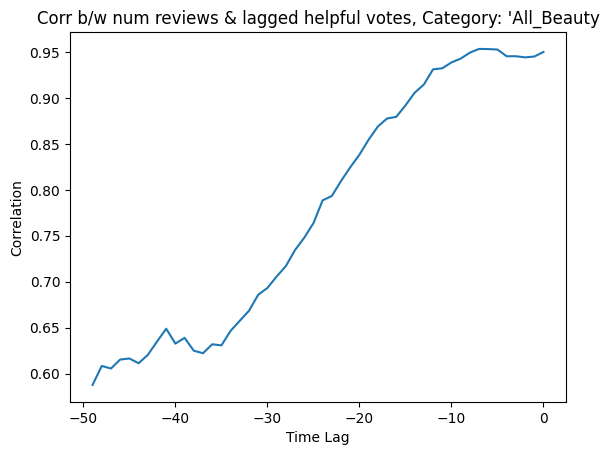

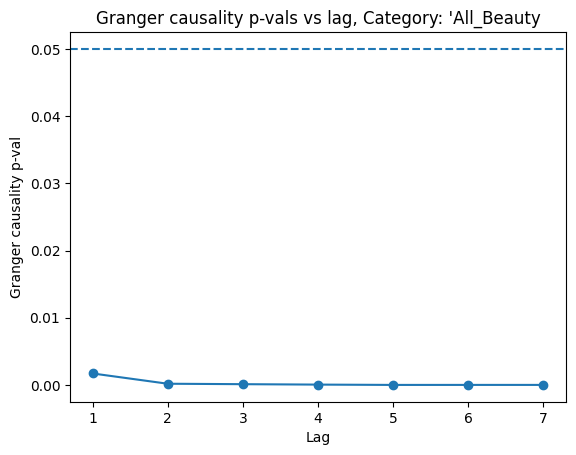

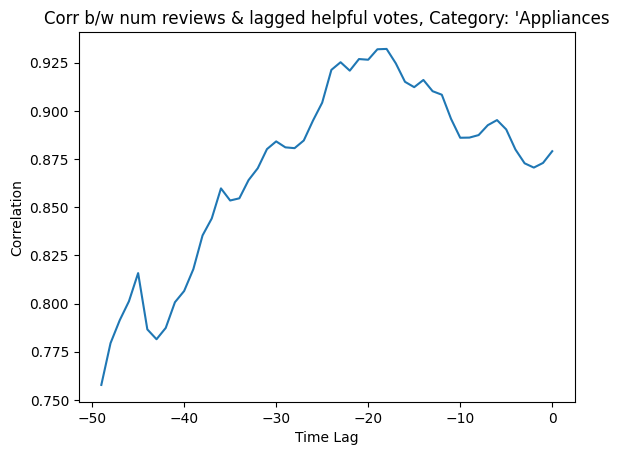

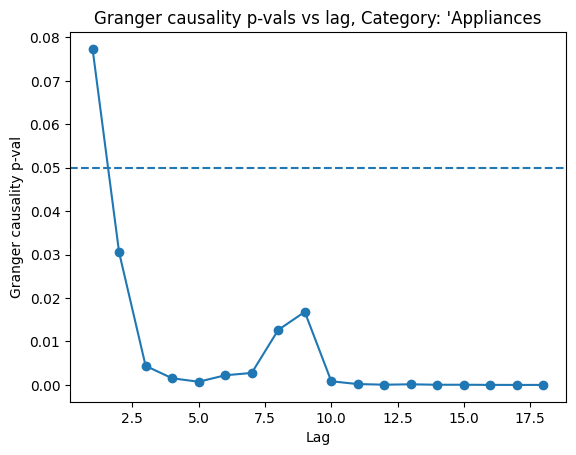

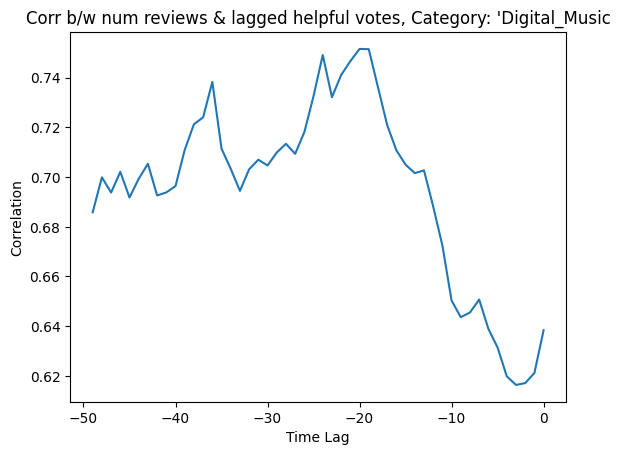

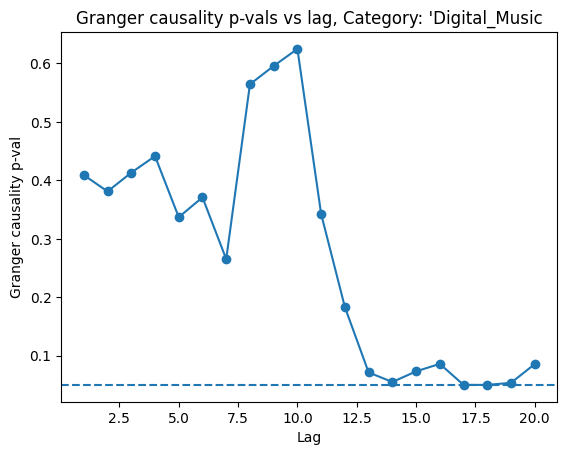

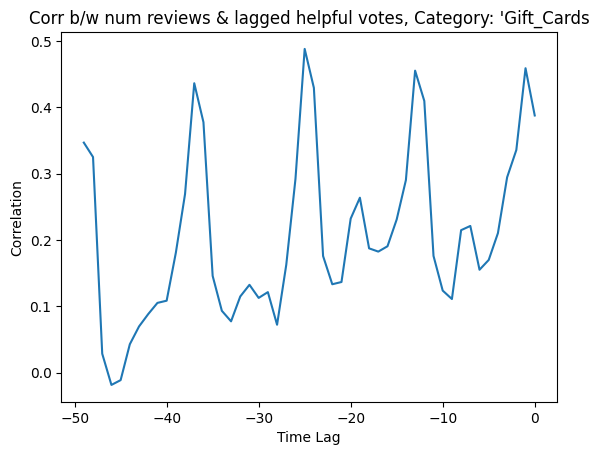

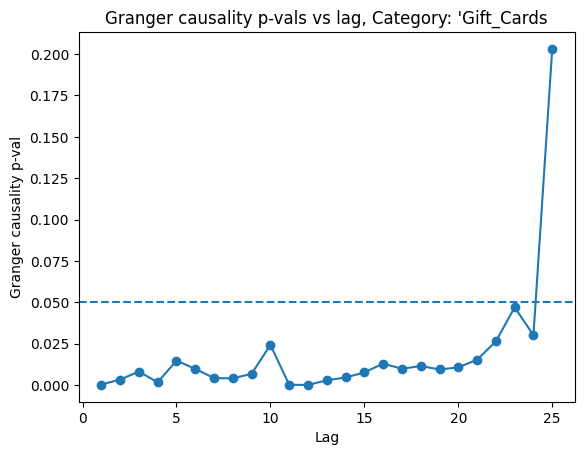

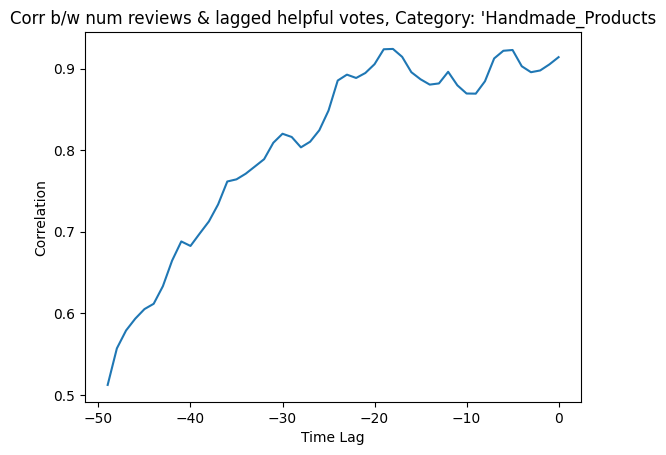

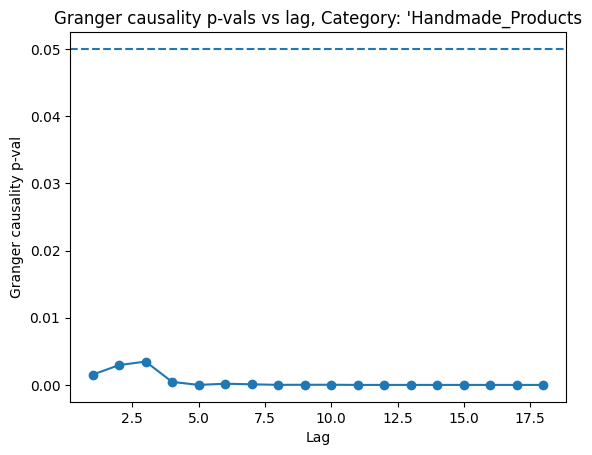

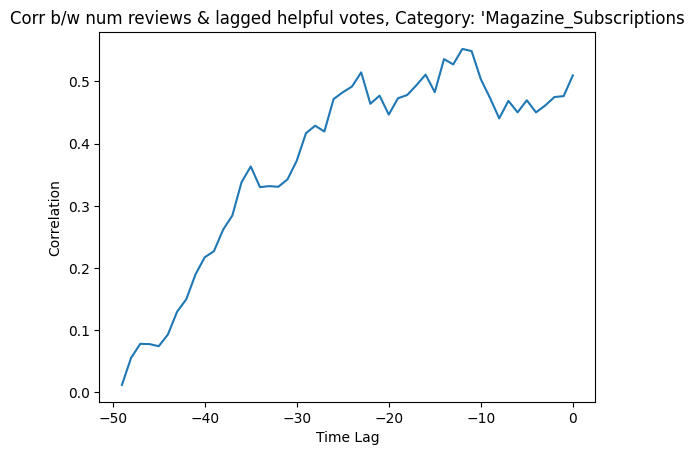

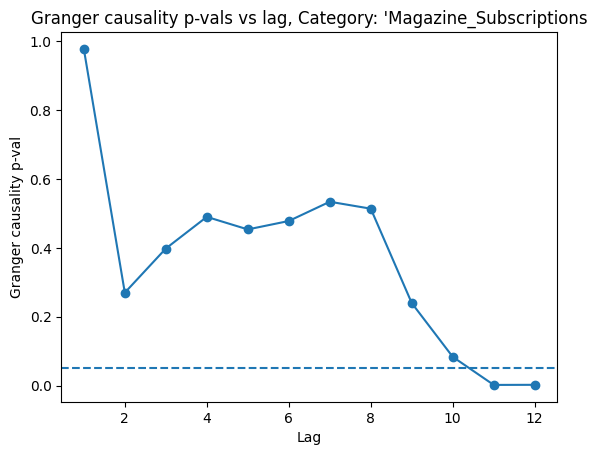

In [4]:
for category in categories:
    time, num_reviews, helpful_votes = plot_data[category]
    run_tests(time, num_reviews, helpful_votes, category = category)

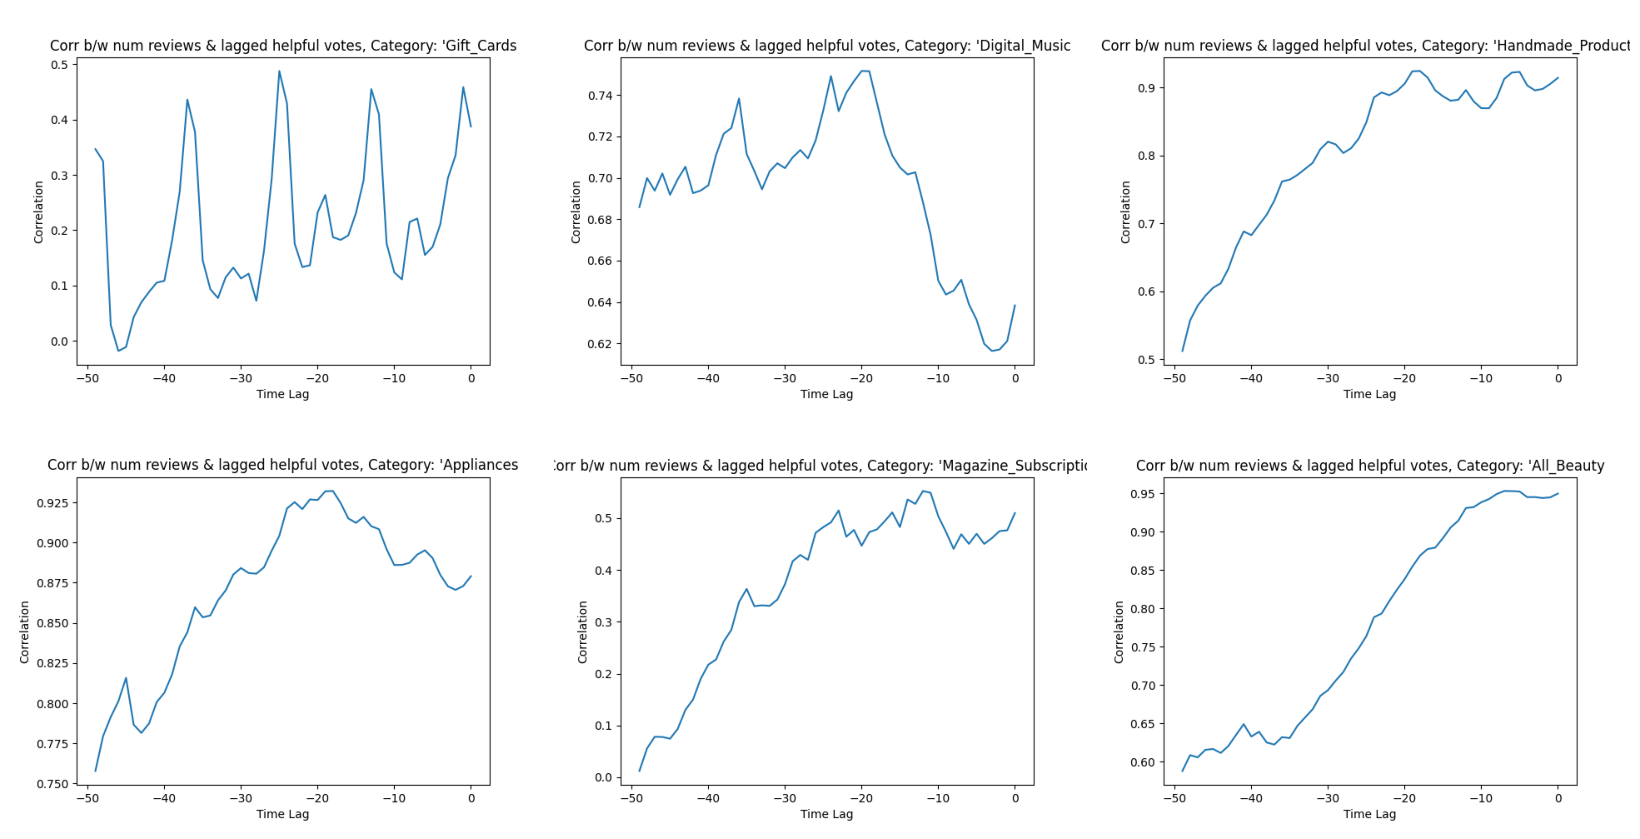

In [7]:
# Uncomment cell to generate a single figure with all the correlation plots

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

contents = os.listdir("plots/")
contents = list(filter(lambda x: x[:4] == "corr", contents))
image_files = list(map(lambda x: "plots/" + x, contents))

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, ax in enumerate(axes):
    img = mpimg.imread(image_files[i])
    ax.imshow(img)
    ax.axis('off')

plt.subplots_adjust(left=0.05, right=0.95, top=0.9, bottom=0.05, wspace=0.02, hspace=-0.3)

plt.savefig("plots/categories_correlation.png")
plt.show()


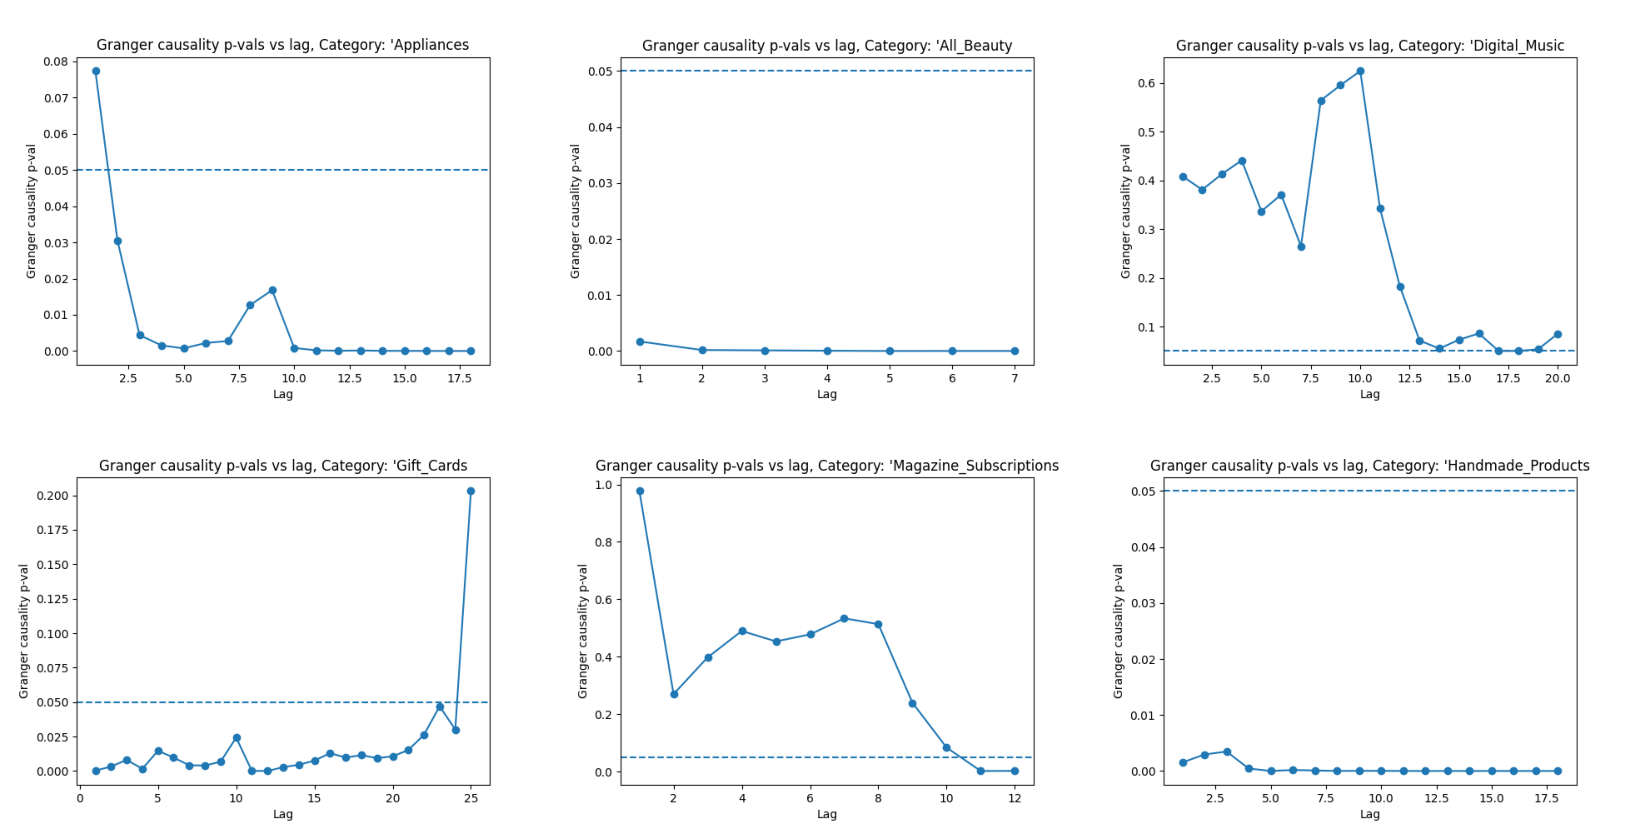

In [6]:
# Uncomment cell to generate a single figure with all the granger plots

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

contents = os.listdir("plots/")
contents = list(filter(lambda x: x[:7] == "granger", contents))
image_files = list(map(lambda x: "plots/" + x, contents))

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, ax in enumerate(axes):
    img = mpimg.imread(image_files[i])
    ax.imshow(img)
    ax.axis('off')

plt.subplots_adjust(left=0.05, right=0.95, top=0.9, bottom=0.05, wspace=0.02, hspace=-0.3)

plt.savefig("plots/categories_granger.png")
plt.show()


### Observations:
- Correlation seems to increase as we use data from months that are more recent, but the increase is not linear
- For some categories, the highest correlated month is actually a few months back (not the most recent month)
- In the OLS analysis, we see that helpful votes for the highest correlated month is positively impacting num reviews with a p-value well below 0.01
- The Durbin-Watson metric is between 0.7 and 1.0 for all the OLS tests, which indicates moderate amounts of autocorrelation
- The Granger Causality test tells us that adding more months does not necessarily give us high-confidence relationships. A general trend though is a decrease in p-value to below the threshold of alpha = 0.05 as we add more months.